# Proyecto de Aula: Modelado y análisis de la red del Metro de Madrid

**Asignaturas**: Algoritmos y Programación - Matemáticas Discretas
**Semestre**: 2026-2

Este notebook integra los algoritmos, métricas y visualizaciones desarrollados para analizar la red del Metro de Madrid usando teoría de grafos.

## 1. Importación de Módulos y Construcción del Grafo

El grafo tiene 291 nodos y 338 aristas.


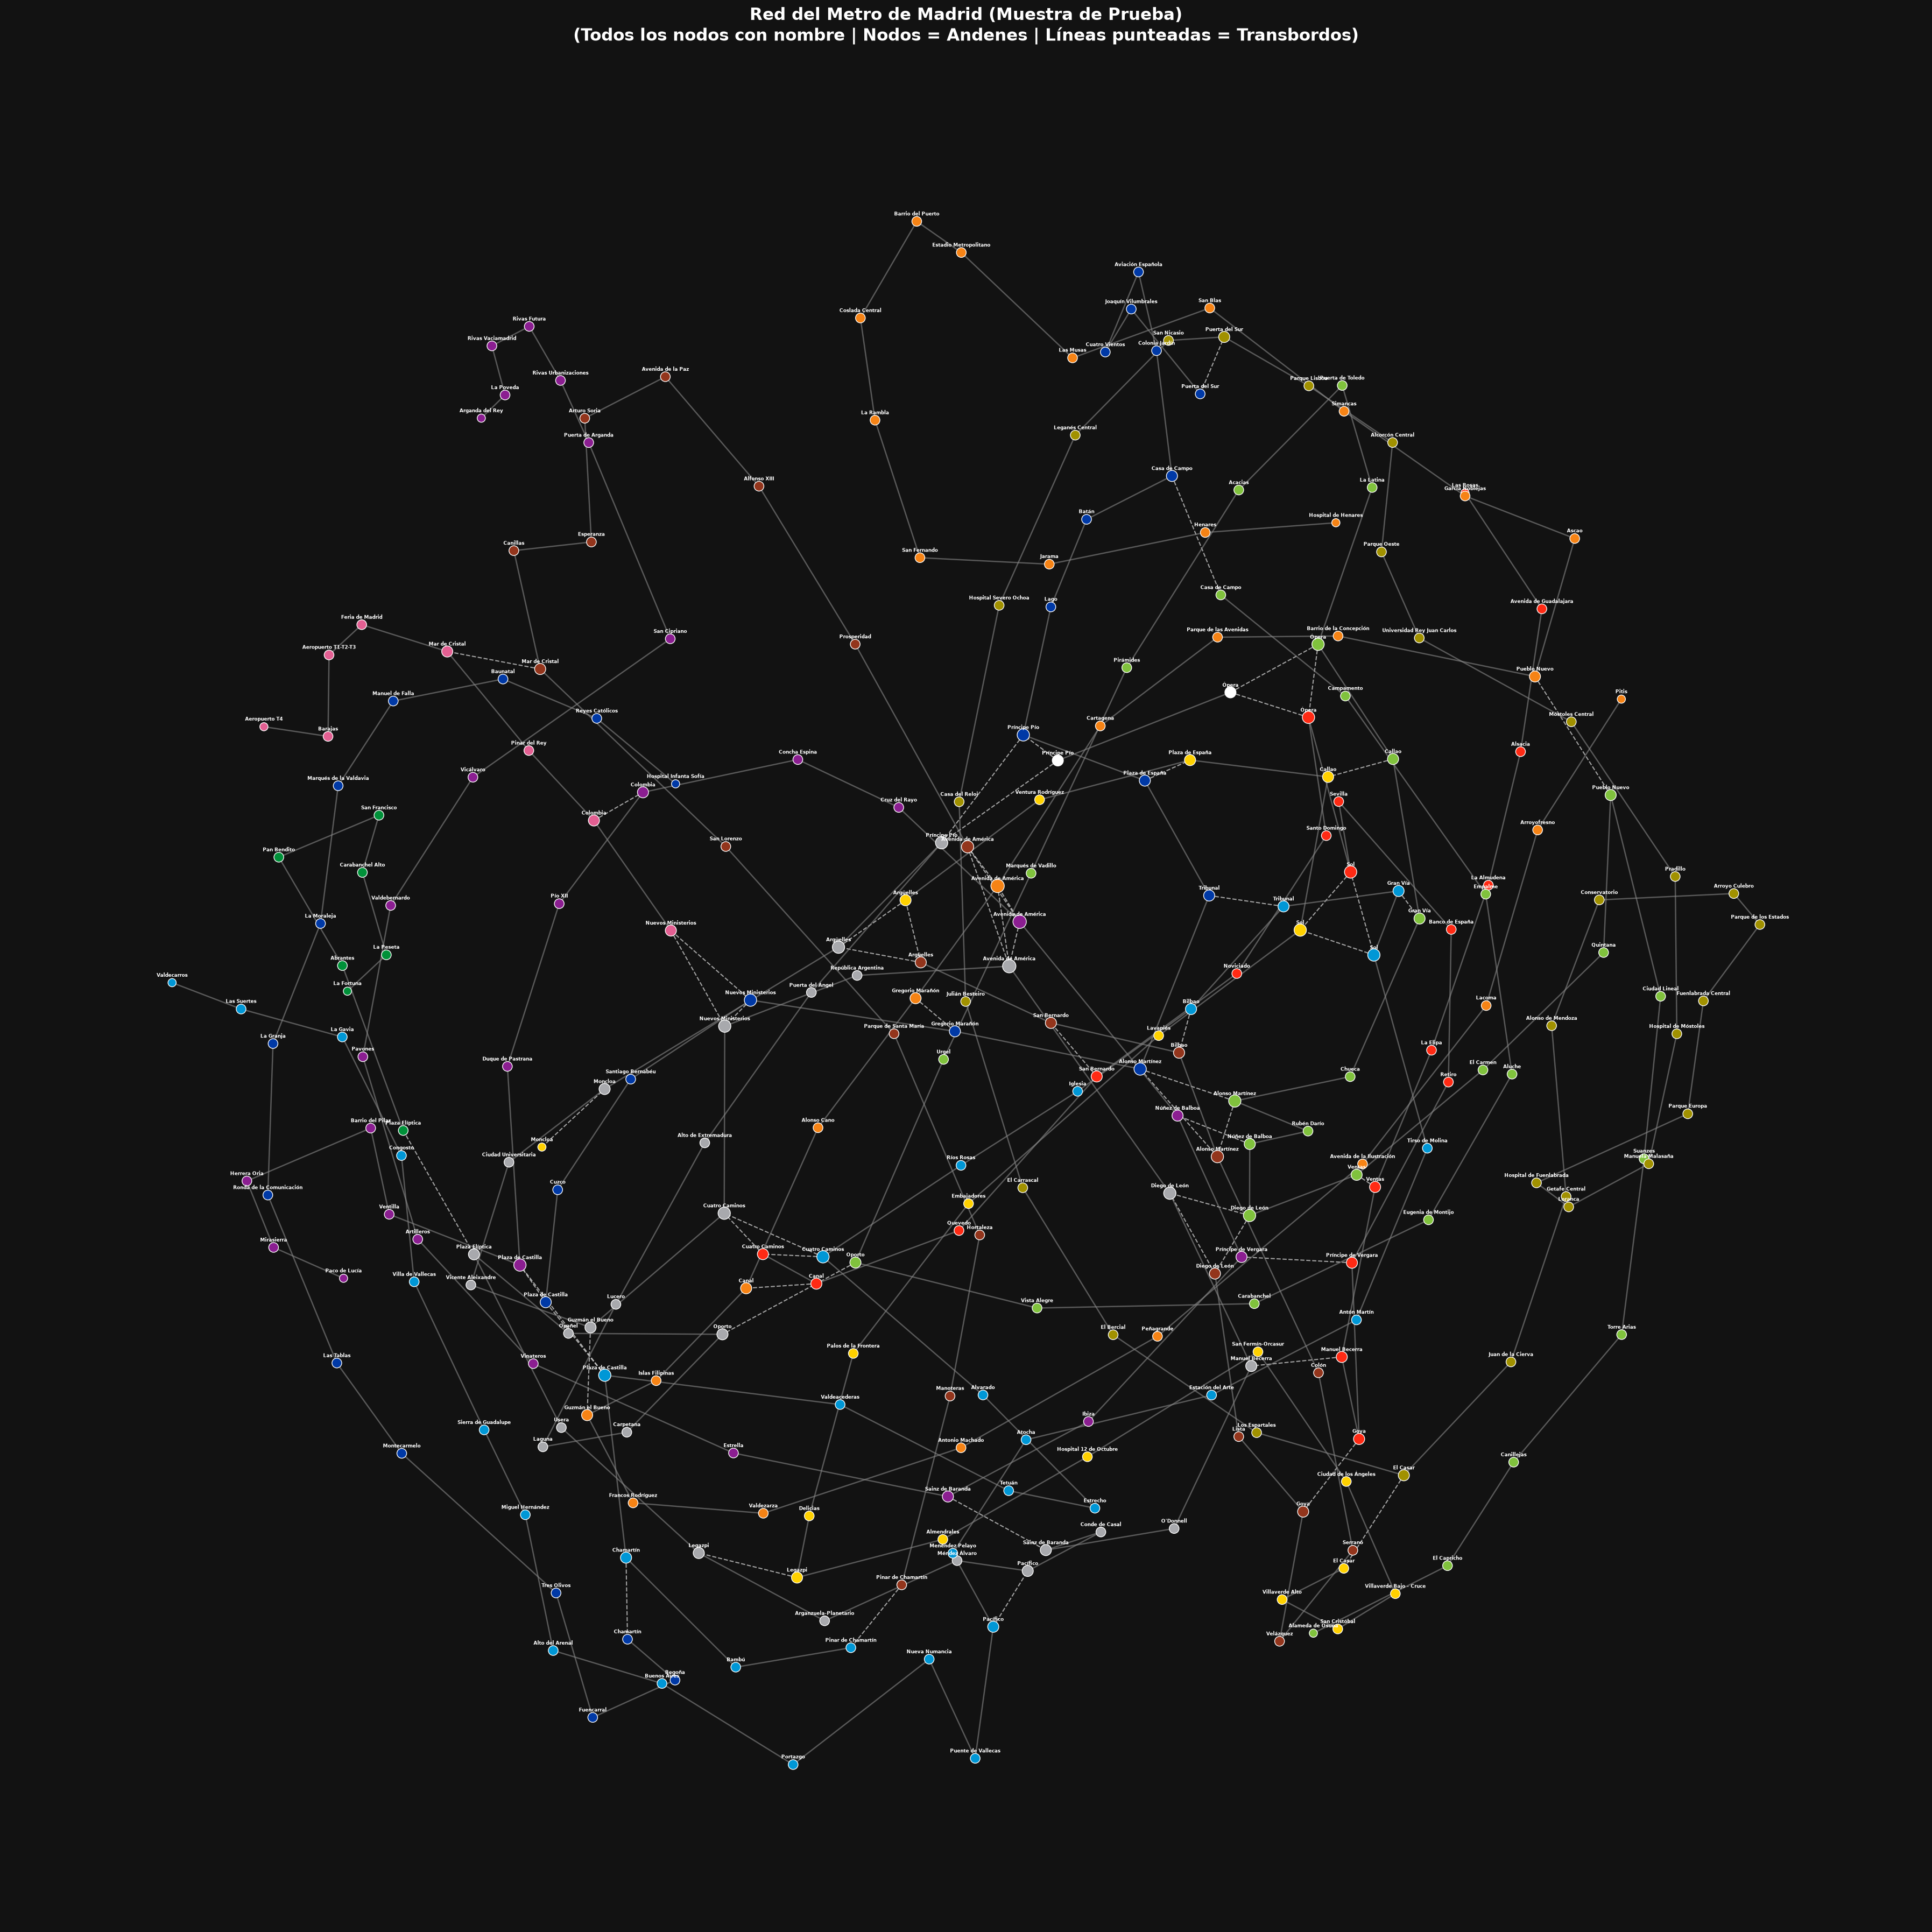

In [ ]:
import sys
import os
sys.path.append(os.path.abspath('../src'))

from graph_builder import load_data, build_metro_graph
from algorithms import compare_routes
from metrics import get_all_metrics, get_top_stations_by_degree, get_top_stations_by_betweenness
from robustness import identify_articulation_points, simulate_node_removal, identify_critical_stations
from visualization import plot_graph_matplotlib, plot_graph_pyvis, plot_route_matplotlib, plot_failed_station_matplotlib

# Cargar datos y construir grafo
data = load_data('../data/metro_madrid.json')
G = build_metro_graph(data)
print(f"El grafo tiene {G.number_of_nodes()} nodos y {G.number_of_edges()} aristas.")
plot_graph_matplotlib(G, title="Red del Metro de Madrid (Muestra de Prueba)")


## 2. Cálculo de la Ruta Óptima 


--- Rutas desde sevilla hasta bilbao ---
Dijkstra (menor tiempo):
  Ruta: ['Sevilla [L2]', 'Sol [L2]', 'Sol [L1]', 'Gran Vía [L1]', 'Tribunal [L1]', 'Bilbao [L1]']
  Tiempo total: 07:54 minutos

BFS (menor número de paradas):
  Ruta: ['Sevilla [L2]', 'Sol [L2]', 'Sol [L1]', 'Gran Vía [L1]', 'Tribunal [L1]', 'Bilbao [L1]']
  Total de paradas: 4


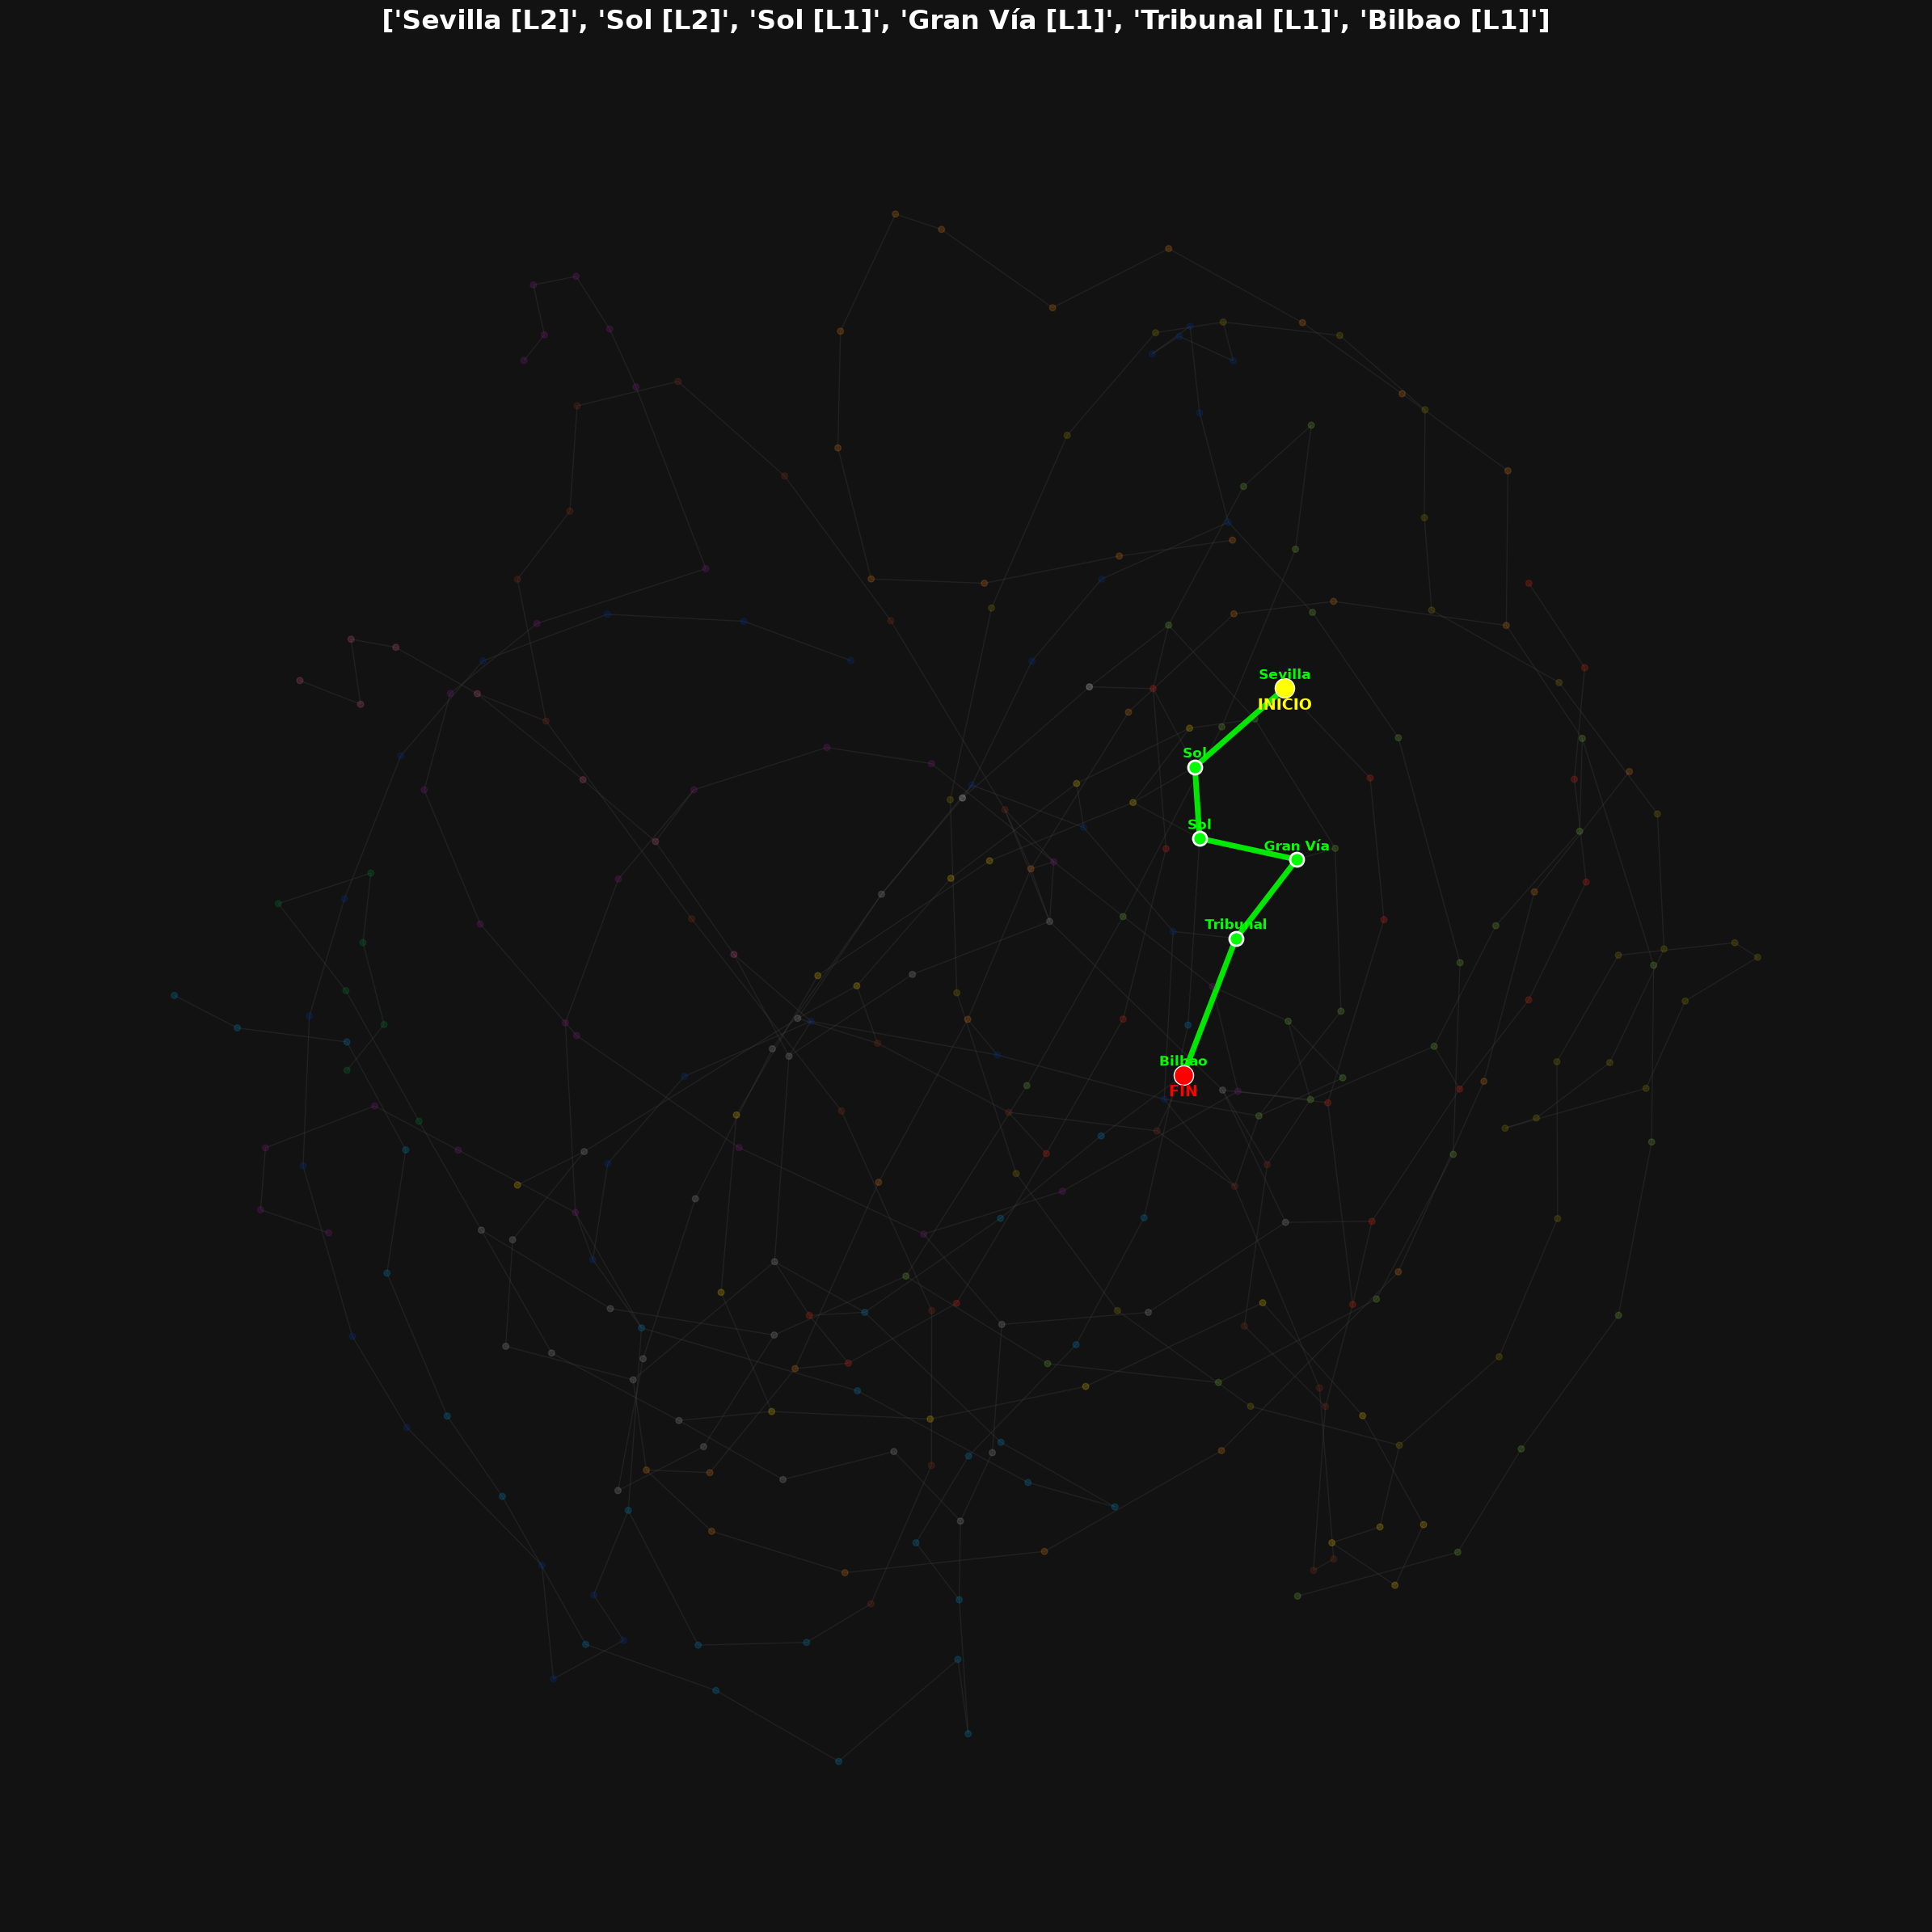

In [2]:
origen = 'sevilla'
destino = 'bilbao'

rutas = compare_routes(G, origen, destino)

print(f"--- Rutas desde {origen} hasta {destino} ---")
print("Dijkstra (menor tiempo):")
print(f"  Ruta: {rutas['dijkstra']['path']}")
print(f"  Tiempo total: {rutas['dijkstra']['time']} (formato mm:ss)")
print(f"  Paradas de tren: {rutas['dijkstra']['stops']} | Transbordos: {rutas['dijkstra']['transfers']}")
print("\nBFS (menor número de paradas):")
print(f"  Ruta: {rutas['bfs']['path']}")
print(f"  Tiempo total: {rutas['bfs']['time']} (formato mm:ss)")
print(f"  Total de paradas: {rutas['bfs']['stops']}")
plot_route_matplotlib(G, rutas['dijkstra']['path'], rutas['bfs']['path'])


## 3. Métricas de Teoría de Grafos

In [ ]:
metricas = get_all_metrics(G)

print("--- Métricas Globales de la Red ---")
print(f"Densidad: {metricas['density']:.4f}")
print(f"Diámetro: {metricas['diameter']}")

# Estaciones físicas únicas con mayor conectividad (sin repetición por línea)
print("\nEstaciones físicas con mayor grado (Top 5 sin repetición):")
for idx, est in enumerate(metricas['top_stations_degree'], 1):
    lineas_str = ', '.join(est['lineas'])
    print(f"  {idx}. {est['nombre']}: {est['grado_total']} conexiones totales (Líneas: {lineas_str})")

# Estaciones físicas únicas más centrales (Betweenness Centrality)
print("\nEstaciones físicas más centrales (Top 5 sin repetición):")
for idx, est in enumerate(metricas['top_stations_betweenness'], 1):
    lineas_str = ', '.join(est['lineas'])
    print(f"  {idx}. {est['nombre']}: Centralidad = {est['centralidad']} (Líneas: {lineas_str})")


--- Métricas de la Red ---
Densidad: 0.0080
Diámetro: 46

Estaciones con mayor grado (top 3):
  - Avenida de América [L9]: 5
  - Avenida de América [L7]: 5
  - Avenida de América [L6]: 5
  - Príncipe Pío [L10]: 4
  - Príncipe Pío [L6]: 4
  - Argüelles [L6]: 4
  - Cuatro Caminos [L1]: 4
  - Cuatro Caminos [L6]: 4
  - Nuevos Ministerios [L10]: 4
  - Nuevos Ministerios [L6]: 4

Estaciones más centrales (top 3):
  - Legazpi [L3]: 0.1544
  - Pacífico [L6]: 0.1475
  - Sainz de Baranda [L6]: 0.1373
  - Plaza de Castilla [L1]: 0.1354
  - Príncipe Pío [L10]: 0.1339
  - Tribunal [L10]: 0.1337
  - Almendrales [L3]: 0.1319
  - Plaza de España [L10]: 0.1312
  - Alonso Martínez [L10]: 0.1303
  - Diego de León [L6]: 0.1302


## 4. Análisis de Conectividad y Robustez

--- Puntos de Articulación ---
Nodos críticos que desconectarían la red si fallan: ['La Peseta [L11]', 'Carabanchel Alto [L11]', 'San Francisco [L11]', 'Pan Bendito [L11]', 'Abrantes [L11]', 'Arroyofresno [L7]', 'Lacoma [L7]', 'Avenida de la Ilustración [L7]', 'Peñagrande [L7]', 'Antonio Machado [L7]', 'Valdezarza [L7]', 'Francos Rodríguez [L7]', 'Guzmán el Bueno [L7]', 'Las Suertes [L1]', 'La Gavia [L1]', 'Congosto [L1]', 'Villa de Vallecas [L1]', 'Sierra de Guadalupe [L1]', 'Miguel Hernández [L1]', 'Alto del Arenal [L1]', 'Buenos Aires [L1]', 'Portazgo [L1]', 'Nueva Numancia [L1]', 'Puente de Vallecas [L1]', 'Pacífico [L1]', 'Mirasierra [L9]', 'Herrera Oria [L9]', 'Barrio del Pilar [L9]', 'Ventilla [L9]', 'Plaza de Castilla [L9]', 'Barajas [L8]', 'Aeropuerto T1-T2-T3 [L8]', 'Feria de Madrid [L8]', 'Mar de Cristal [L8]', 'La Poveda [L9]', 'Rivas Vaciamadrid [L9]', 'Rivas Futura [L9]', 'Rivas Urbanizaciones [L9]', 'Puerta de Arganda [L9]', 'San Cipriano [L9]', 'Vicálvaro [L9]', 'Valdeb

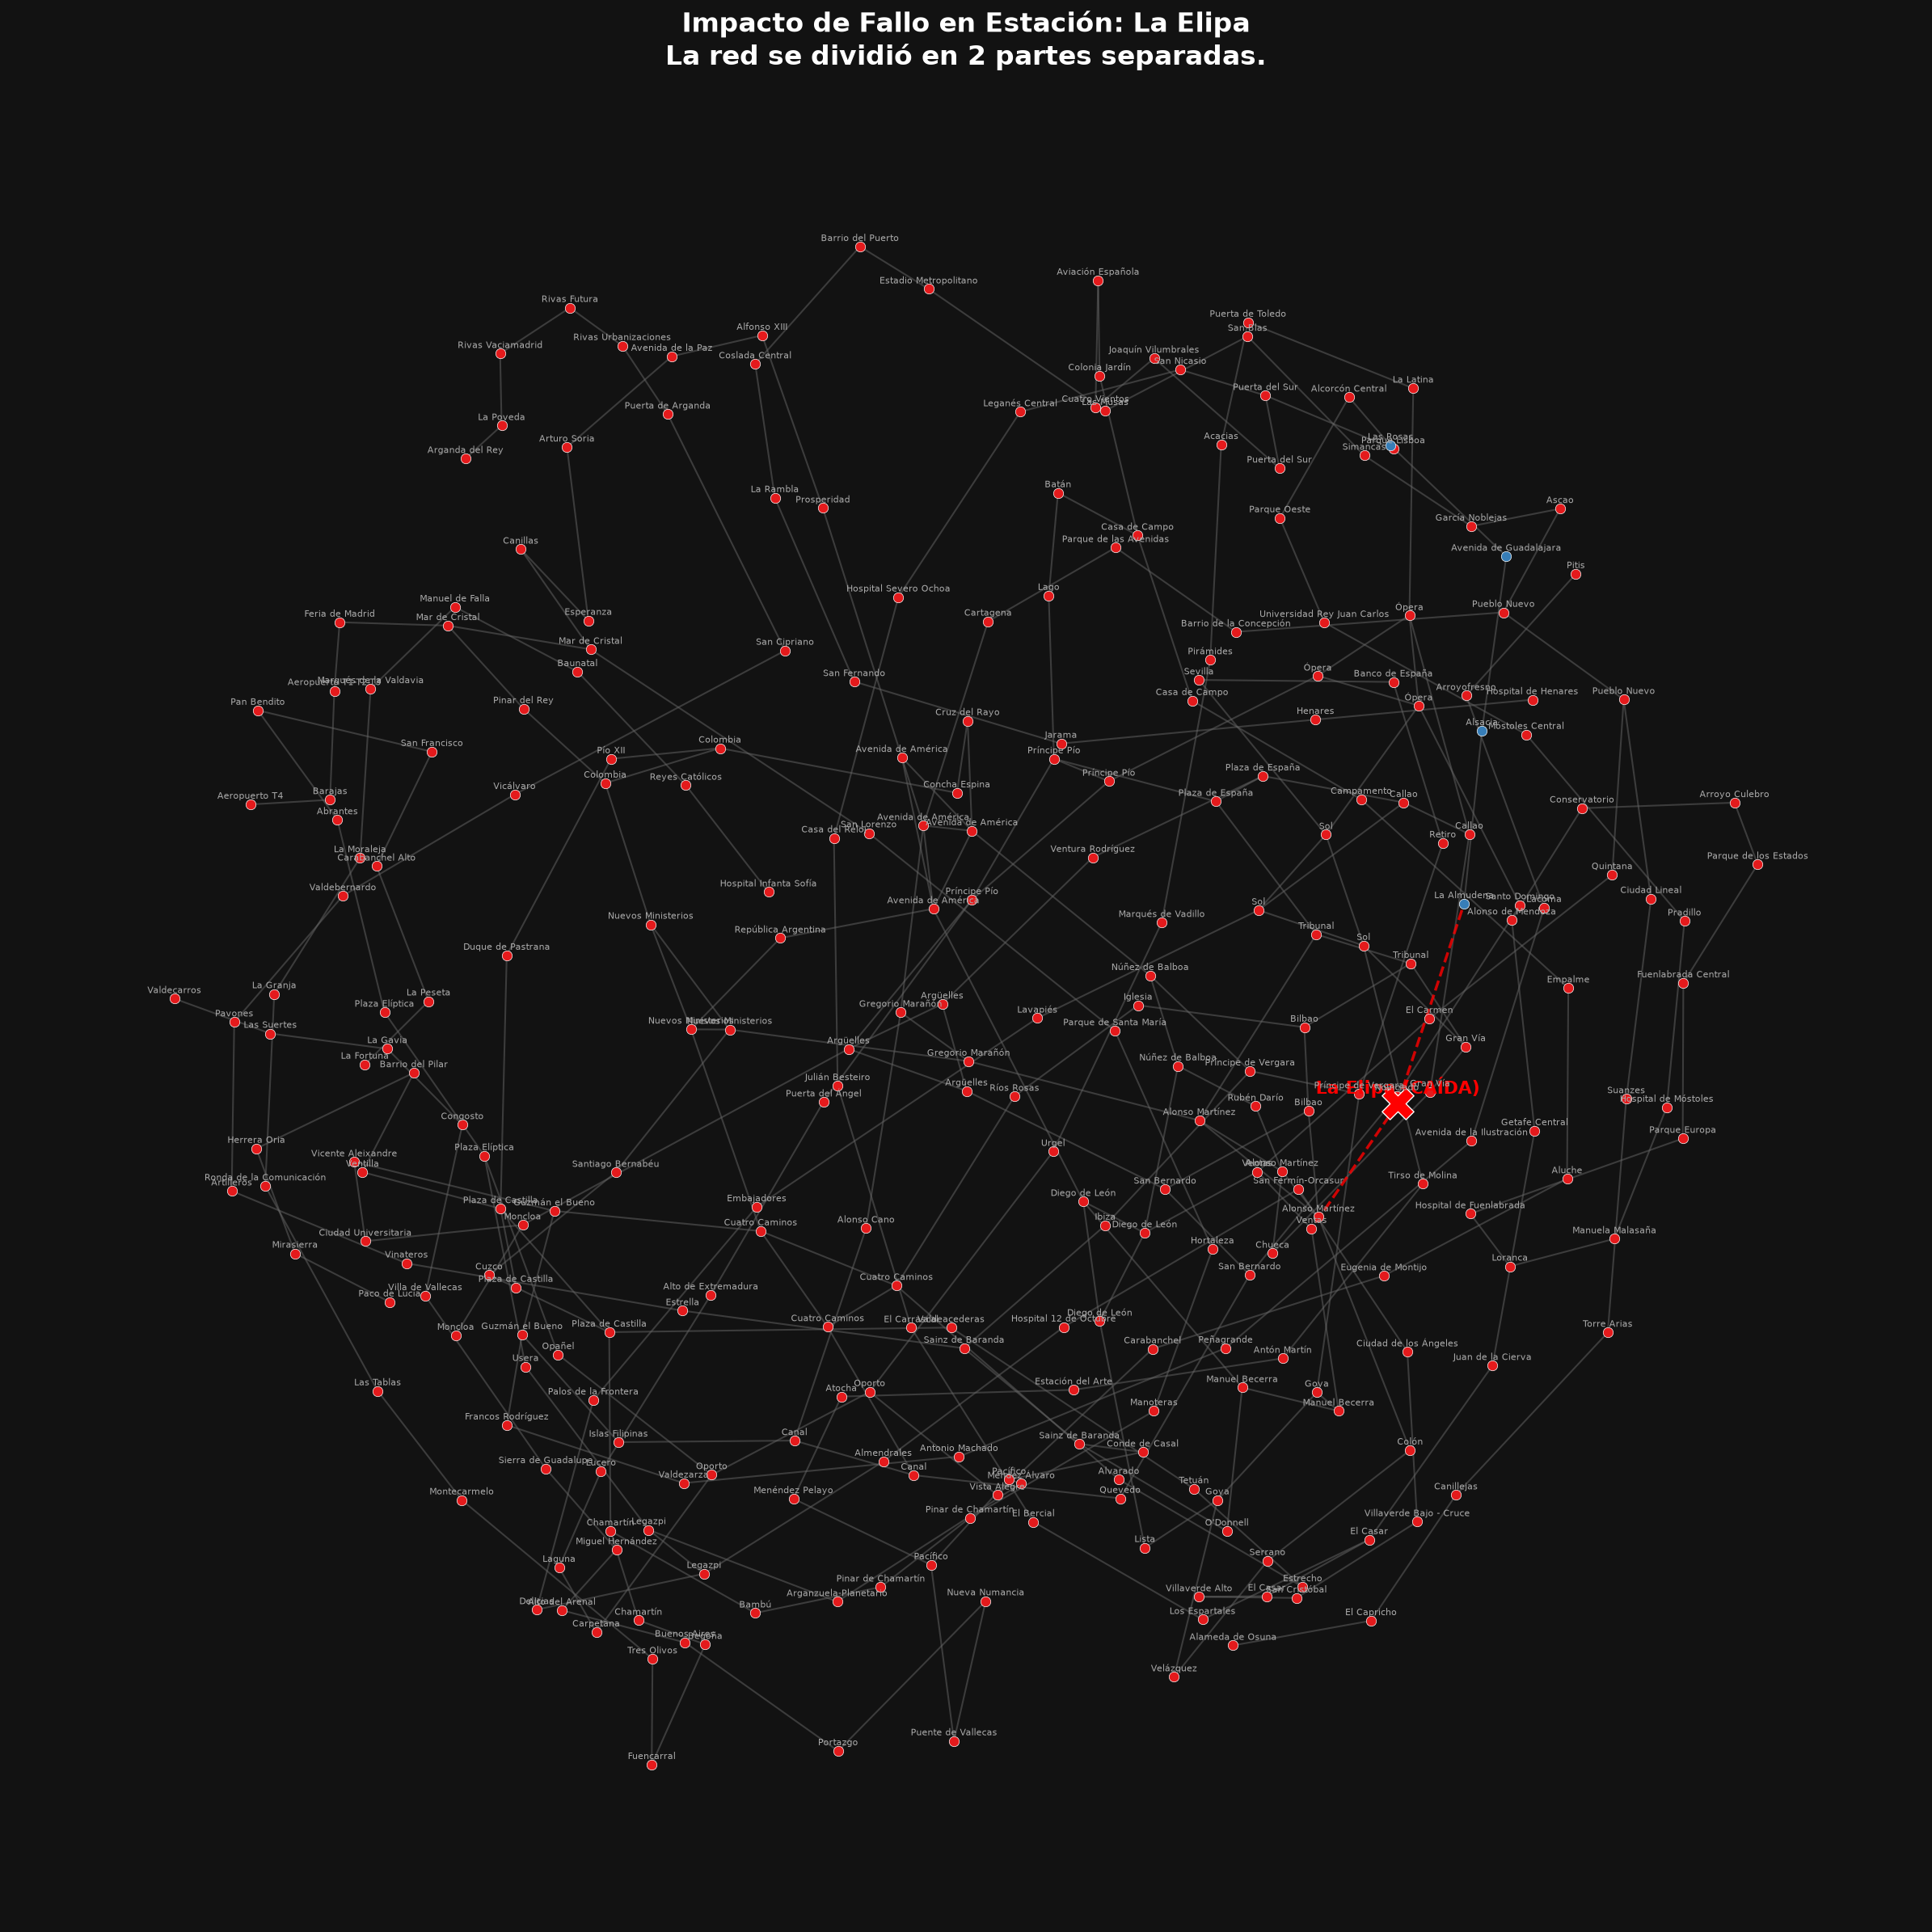

In [4]:
# 1. Análisis de estaciones críticas a nivel de red completa
criticas = identify_critical_stations(G, top_n=5)
print("--- Estaciones Físicas Críticas (Cierre Completo Desconecta la Red) ---")
for c in criticas:
    print(f"  - {c['estacion']} ({', '.join(c['lineas'])}): Divide la red en {c['num_components']} partes (Aísla {c['isolated_stations_count']} andenes)")

# 2. Simulación de eliminación de estación completa (ej. 'Pueblo Nuevo' o 'Sol')
print("\n--- Simulación de Cierre de Estación Completa ---")
estacion_fallo = 'Pueblo Nuevo'  # Se puede ingresar el nombre de la estación completa o un andén
resultado = simulate_node_removal(G, estacion_fallo)

print(f"Simulando el cierre completo de: '{resultado['removed_station']}'")
print(f"Andenes eliminados ({resultado['num_removed_nodes']}): {resultado['removed_nodes']}")
print(f"¿Sigue conectada la red?: {'Sí' if resultado['is_connected'] else 'No'}")
print(f"Número de fragmentos resultantes: {resultado['num_components']}")
print(f"Tamaño de los componentes: {resultado['component_sizes']}")

# Visualizar impacto del cierre en el mapa del metro
plot_failed_station_matplotlib(G, estacion_fallo)


In [5]:
plot_graph_pyvis(G)

Visualización interactiva guardada en: metro_madrid_pyvis.html
